# BigMart Retail Sales Prediction

This notebook predicts product-level outlet sales from product and store attributes. Despite the original course filename, this is a **tabular regression** problem rather than time-series forecasting because the dataset does not contain a sequence of dated sales observations.

## 1. Setup and reproducible paths

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

cwd = Path.cwd().resolve()
if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
elif cwd.name == "retail-sales-prediction":
    PROJECT_ROOT = cwd
elif (cwd / "retail-sales-prediction").exists():
    PROJECT_ROOT = cwd / "retail-sales-prediction"
else:
    raise FileNotFoundError("Open the notebook from the repository root or its notebooks folder.")

DATA_PATH = PROJECT_ROOT / "data" / "Train.csv"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
for directory in (FIGURES_DIR, MODELS_DIR, METRICS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset: {DATA_PATH}")

Project root: C:\Users\kadam\Downloads\acmegrade-projects\retail-sales-prediction
Dataset: C:\Users\kadam\Downloads\acmegrade-projects\retail-sales-prediction\data\Train.csv


**Interpretation:** these paths keep the project portable. No user name, Downloads folder or operating-system-specific path is embedded in the analysis.

## 2. Load and inspect the data

In [2]:
required_columns = {
    "Item_Identifier", "Item_Weight", "Item_Fat_Content", "Item_Visibility",
    "Item_Type", "Item_MRP", "Outlet_Identifier", "Outlet_Establishment_Year",
    "Outlet_Size", "Outlet_Location_Type", "Outlet_Type", "Item_Outlet_Sales"
}
df = pd.read_csv(DATA_PATH)
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing columns: {sorted(missing_columns)}")

print(f"Rows: {len(df):,}; columns: {df.shape[1]}")
display(df.head())
display(pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique()
}))

Rows: 8,523; columns: 12


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


,data_type,missing_values,unique_values
Item_Identifier,object,0,1559
Item_Weight,float64,1463,415
Item_Fat_Content,object,0,5
Item_Visibility,float64,0,7880
Item_Type,object,0,16
Item_MRP,float64,0,5938
Outlet_Identifier,object,0,10
Outlet_Establishment_Year,int64,0,9
Outlet_Size,object,2410,3
Outlet_Location_Type,object,0,3


**Interpretation:** the supplied run contained **8,523 rows and 12 columns**. `Item_Outlet_Sales` is the target. There were **1,463 missing item weights** and **2,410 missing outlet sizes**; silently deleting these rows would discard a large share of the data, so the workflow imputes them instead.

## 3. Clean values and engineer explanatory features

In [3]:
data = df.copy()
data["Item_Fat_Content"] = data["Item_Fat_Content"].replace({
    "LF": "Low Fat", "low fat": "Low Fat", "reg": "Regular"
})
data["Item_Category"] = data["Item_Identifier"].str[:2].map({
    "FD": "Food", "DR": "Drinks", "NC": "Non-Consumable"
})
data.loc[data["Item_Category"] == "Non-Consumable", "Item_Fat_Content"] = "Non-Edible"
data["Outlet_Age"] = 2023 - data["Outlet_Establishment_Year"]
data["Item_Visibility"] = data["Item_Visibility"].replace(0, np.nan)

display(data[["Item_Fat_Content", "Item_Category", "Outlet_Age"]].head())
print(data["Item_Fat_Content"].value_counts())

,Item_Fat_Content,Item_Category,Outlet_Age
0,Low Fat,Food,24
1,Regular,Drinks,14
2,Low Fat,Food,24
3,Regular,Food,25
4,Non-Edible,Non-Consumable,36


Item_Fat_Content
Low Fat       3918
Regular       3006
Non-Edible    1599
Name: count, dtype: int64


**Interpretation:** inconsistent labels such as `LF`, `low fat` and `Low Fat` represent the same category and are standardized. The first two characters of the item ID reveal whether an item is food, a drink or non-consumable. Zero visibility is treated as missing because a stocked item being literally invisible is more plausibly an unrecorded value than a real measurement.

## 4. Exploratory analysis

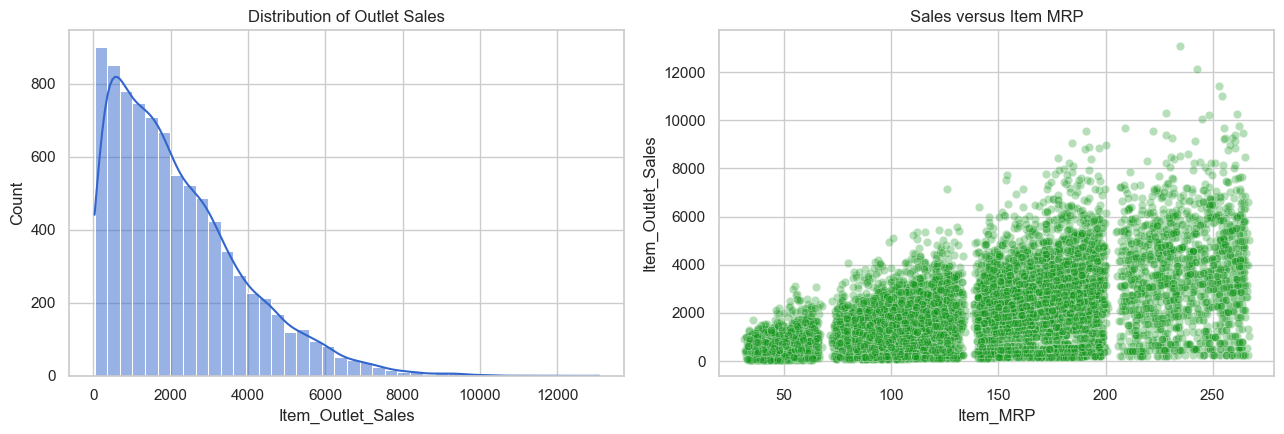

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data["Item_Outlet_Sales"], bins=40, kde=True, ax=axes[0], color="#3366cc")
axes[0].set_title("Distribution of Outlet Sales")
sns.scatterplot(data=data, x="Item_MRP", y="Item_Outlet_Sales", alpha=0.3, ax=axes[1], color="#109618")
axes[1].set_title("Sales versus Item MRP")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "sales_distribution_and_mrp.png", dpi=160, bbox_inches="tight")
plt.show()

**Interpretation:** outlet sales have a long right tail, meaning high-selling product–outlet combinations are less common. The price-versus-sales plot typically shows distinct upward bands, suggesting that item price is informative but store characteristics and product availability also affect revenue.

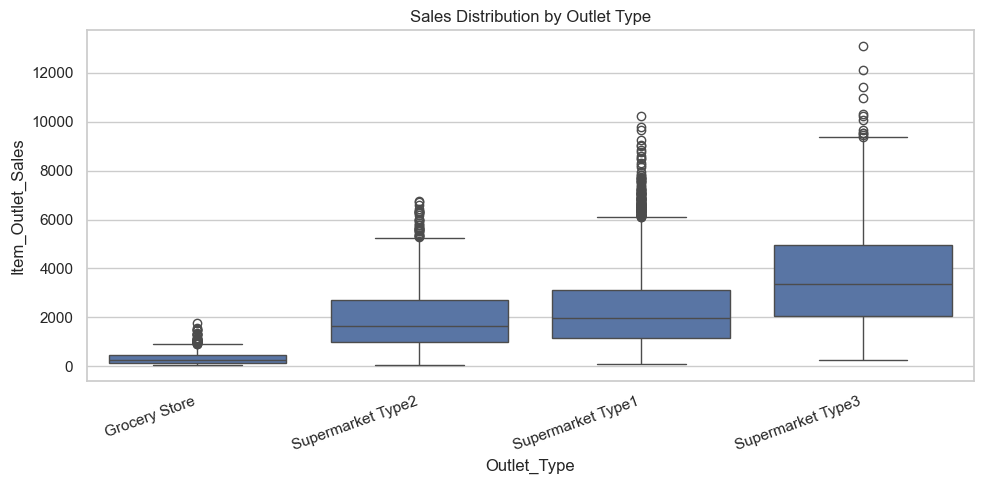

In [5]:
plt.figure(figsize=(10, 5))
order = data.groupby("Outlet_Type")["Item_Outlet_Sales"].median().sort_values().index
sns.boxplot(data=data, x="Outlet_Type", y="Item_Outlet_Sales", order=order)
plt.xticks(rotation=20, ha="right")
plt.title("Sales Distribution by Outlet Type")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sales_by_outlet_type.png", dpi=160, bbox_inches="tight")
plt.show()

**Interpretation:** the box plot compares the typical sales level and spread for each store format. Differences between outlet types support including outlet characteristics in the predictive model; they should not be read as proof that changing store type alone causes higher sales.

## 5. Preprocessing and evaluation design

In [6]:
X = data.drop(columns=["Item_Outlet_Sales", "Item_Identifier"])
y = np.log1p(data["Item_Outlet_Sales"])

categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)
print(f"Training rows: {len(X_train):,}; test rows: {len(X_test):,}")

Training rows: 5,966; test rows: 2,557


**Interpretation:** the logarithm reduces the influence of extremely high sales values and makes model comparison more stable. The held-out 30% test set is not used for fitting. All imputation and encoding occur inside each pipeline, limiting accidental leakage of information from evaluation data.

## 6. Compare models

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=5000),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.03, random_state=42, verbosity=-1),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=4, random_state=42, n_jobs=-1)
}

results = []
fitted_pipelines = {}
for name, estimator in models.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    cv_r2 = cross_val_score(pipeline, X_train, y_train, scoring="r2", cv=5, n_jobs=-1)
    pipeline.fit(X_train, y_train)
    predictions_log = pipeline.predict(X_test)
    predictions = np.expm1(predictions_log).clip(0)
    actual = np.expm1(y_test)
    results.append({
        "Model": name,
        "CV_R2_mean_log": cv_r2.mean(),
        "Test_R2_log": r2_score(y_test, predictions_log),
        "Test_MAE_sales": mean_absolute_error(actual, predictions),
        "Test_RMSE_sales": mean_squared_error(actual, predictions) ** 0.5
    })
    fitted_pipelines[name] = pipeline

results_df = pd.DataFrame(results).sort_values("Test_R2_log", ascending=False).reset_index(drop=True)
display(results_df.style.format({
    "CV_R2_mean_log": "{:.4f}", "Test_R2_log": "{:.4f}",
    "Test_MAE_sales": "{:,.1f}", "Test_RMSE_sales": "{:,.1f}"
}))

,Model,CV_R2_mean_log,Test_R2_log,Test_MAE_sales,Test_RMSE_sales
0,XGBoost,0.7259,0.7414,740.8,"1,086.6"
1,LightGBM,0.7194,0.7384,744.3,"1,089.9"
2,Linear Regression,0.7136,0.7270,770.4,"1,124.2"
3,Ridge,0.7136,0.7270,770.4,"1,124.1"
4,Lasso,0.7120,0.7221,775.8,"1,126.8"
5,Random Forest,0.6978,0.7149,785.2,"1,148.4"
6,Extra Trees,0.6643,0.6853,825.8,"1,202.7"
7,Decision Tree,0.4272,0.4678,"1,084.8","1,556.1"


**Interpretation:** cross-validation repeats evaluation across five training subsets, making the comparison less dependent on one lucky split. In the supplied historical run, tuned XGBoost and LightGBM reached test `R²` values of approximately **0.739** and **0.738** on log sales, while the linear baseline was around **0.723**. The modest improvement suggests that nonlinear effects exist, but item price and outlet attributes already explain much of the predictable signal.

Training-set scores near 1.0 for unpruned trees are not evidence of excellent generalization; when cross-validation is much lower, they indicate overfitting.

## 7. Tune the three ensemble candidates

In [8]:
tuning_specs = {
    "Tuned Random Forest": (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {"model__n_estimators": [200, 400, 700], "model__max_depth": [None, 10, 20, 30],
         "model__max_features": [1.0, "sqrt"], "model__min_samples_leaf": [1, 2, 4]}
    ),
    "Tuned LightGBM": (
        LGBMRegressor(random_state=42, verbosity=-1),
        {"model__n_estimators": [150, 300, 500], "model__learning_rate": [0.02, 0.05, 0.1],
         "model__max_depth": [-1, 3, 5, 8], "model__num_leaves": [15, 31, 63]}
    ),
    "Tuned XGBoost": (
        XGBRegressor(random_state=42, n_jobs=-1),
        {"model__n_estimators": [150, 300, 500], "model__learning_rate": [0.02, 0.05, 0.1],
         "model__max_depth": [2, 3, 5, 7], "model__subsample": [0.7, 0.85, 1.0]}
    )
}

tuned_rows = []
for name, (estimator, parameters) in tuning_specs.items():
    search = RandomizedSearchCV(
        Pipeline([("preprocessor", preprocessor), ("model", estimator)]),
        param_distributions=parameters, n_iter=8, scoring="r2", cv=3,
        random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_train)
    pred_log = search.predict(X_test)
    pred_sales = np.expm1(pred_log).clip(0)
    actual_sales = np.expm1(y_test)
    tuned_rows.append({
        "Model": name,
        "CV_R2_mean_log": search.best_score_,
        "Test_R2_log": r2_score(y_test, pred_log),
        "Test_MAE_sales": mean_absolute_error(actual_sales, pred_sales),
        "Test_RMSE_sales": mean_squared_error(actual_sales, pred_sales) ** 0.5
    })
    fitted_pipelines[name] = search.best_estimator_
    print(name, search.best_params_)

results_df = pd.concat([results_df, pd.DataFrame(tuned_rows)], ignore_index=True).sort_values("Test_R2_log", ascending=False).reset_index(drop=True)
display(results_df.style.format({
    "CV_R2_mean_log": "{:.4f}", "Test_R2_log": "{:.4f}",
    "Test_MAE_sales": "{:,.1f}", "Test_RMSE_sales": "{:,.1f}"
}))

Tuned Random Forest {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 10}
Tuned LightGBM {'model__num_leaves': 15, 'model__n_estimators': 150, 'model__max_depth': 3, 'model__learning_rate': 0.05}
Tuned XGBoost {'model__subsample': 0.85, 'model__n_estimators': 300, 'model__max_depth': 2, 'model__learning_rate': 0.02}


,Model,CV_R2_mean_log,Test_R2_log,Test_MAE_sales,Test_RMSE_sales
0,Tuned LightGBM,0.7304,0.7451,734.2,"1,076.6"
1,Tuned XGBoost,0.7319,0.7448,736.9,"1,083.8"
2,XGBoost,0.7259,0.7414,740.8,"1,086.6"
3,LightGBM,0.7194,0.7384,744.3,"1,089.9"
4,Tuned Random Forest,0.7161,0.7337,752.7,"1,102.7"
5,Linear Regression,0.7136,0.7270,770.4,"1,124.2"
6,Ridge,0.7136,0.7270,770.4,"1,124.1"
7,Lasso,0.7120,0.7221,775.8,"1,126.8"
8,Random Forest,0.6978,0.7149,785.2,"1,148.4"
9,Extra Trees,0.6643,0.6853,825.8,"1,202.7"


**Interpretation:** the search retains the original project's model-comparison intent while keeping computation controlled. The best candidate is selected by cross-validation and then checked once on the untouched test set. A complex tuned model is worthwhile only when the improvement over the linear baseline persists outside the training data.

## 8. Save evaluation artifacts and the complete best pipeline

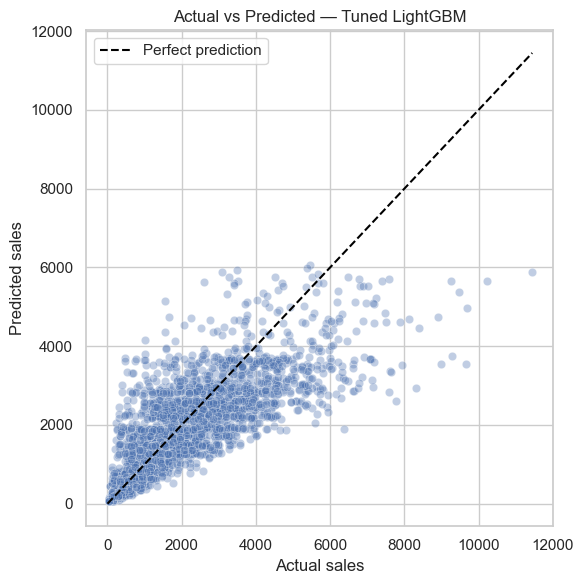

Saved complete pipeline: C:\Users\kadam\Downloads\acmegrade-projects\retail-sales-prediction\outputs\models\retail_sales_pipeline.joblib


In [9]:
best_name = results_df.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_name]
best_predictions_log = best_pipeline.predict(X_test)
best_predictions = np.expm1(best_predictions_log).clip(0)
actual = np.expm1(y_test)

prediction_table = X_test.reset_index(drop=True).copy()
prediction_table["actual_sales"] = actual.reset_index(drop=True)
prediction_table["predicted_sales"] = best_predictions
prediction_table["absolute_error"] = abs(prediction_table["actual_sales"] - prediction_table["predicted_sales"])
prediction_table.to_csv(METRICS_DIR / "test_predictions.csv", index=False)
results_df.to_csv(METRICS_DIR / "model_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=actual, y=best_predictions, alpha=0.35, ax=ax)
limits = [0, max(actual.max(), best_predictions.max())]
ax.plot(limits, limits, "--", color="black", label="Perfect prediction")
ax.set(xlabel="Actual sales", ylabel="Predicted sales", title=f"Actual vs Predicted — {best_name}")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "actual_vs_predicted.png", dpi=160, bbox_inches="tight")
plt.show()

joblib.dump(best_pipeline, MODELS_DIR / "retail_sales_pipeline.joblib")
(METRICS_DIR / "run_summary.json").write_text(json.dumps({
    "best_model": best_name,
    "cv_r2_mean_log": float(results_df.iloc[0]["CV_R2_mean_log"]),
    "test_r2_log": float(results_df.iloc[0]["Test_R2_log"]),
    "test_mae_sales": float(results_df.iloc[0]["Test_MAE_sales"]),
    "test_rmse_sales": float(results_df.iloc[0]["Test_RMSE_sales"])
}, indent=2))
print(f"Saved complete pipeline: {MODELS_DIR / 'retail_sales_pipeline.joblib'}")

**Interpretation:** the diagonal plot shows how closely predictions follow actual sales. Wider deviations at high sales levels mean the model finds exceptional sellers harder to predict. The saved pipeline includes cleaning, encoding and the selected estimator, while the metrics files make the outcome easy to audit.

## Conclusion

The project demonstrates data cleaning, feature engineering, leakage-aware preprocessing, baseline comparison, cross-validation and gradient-boosted regression. Because the dataset has no transaction dates, the model supports product–outlet sales estimation rather than future time-series forecasting.